In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import plotly.express as px

%matplotlib inline


# Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective: Understand the relationship between product categories and their best-seller status.**

In [3]:
# to import a csv file 
amzUK_df = pd.read_csv('C:\\Users\\tevfi\\Desktop\\Ironhack\\lab\\amz_uk_price_prediction_dataset.csv') 

In [4]:
amzUK_df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
amzUK_df['isBestSeller'] = amzUK_df['isBestSeller'].astype(int)

In [6]:
crosstab = pd.crosstab(amzUK_df['category'], amzUK_df['isBestSeller'])
crosstab

isBestSeller,0,1
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [7]:
crosstab['BestSeller_Ratio'] = crosstab[1] / crosstab.sum(axis=1)
sorted_crosstab = crosstab.sort_values(by='BestSeller_Ratio', ascending=False)
print(sorted_crosstab)


isBestSeller                         0    1  BestSeller_Ratio
category                                                     
Grocery                           9008  556          0.058135
Smart Home Security & Lighting      98    6          0.057692
Health & Personal Care            9017  552          0.057686
Mobile Phone Accessories           248   11          0.042471
Power & Hand Tools                8353  306          0.035339
...                                ...  ...               ...
CD, Disc & Tape Players           8798    0          0.000000
General Music-Making Accessories   259    0          0.000000
Snowboard Boots                   1449    0          0.000000
Boxes & Organisers                 911    0          0.000000
eBook Readers & Accessories        246    0          0.000000

[296 rows x 3 columns]


In [8]:
crosstab_for_chi2 = crosstab[[0, 1]]

In [9]:
# Statistical Tests
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association


In [10]:
# Chi-square test for 'category' and 'isBestSeller'
crosstab_for_chi2_statistic, crosstab_for_chi2_p_value, _, _ = chi2_contingency(crosstab_for_chi2)
crosstab_for_chi2_statistic, crosstab_for_chi2_p_value

(36540.20270061387, 0.0)

In [11]:
# Cramér's V, to understand the strength of association between best-seller status and category.
association(crosstab_for_chi2, method="cramer")

0.1222829439760564

In [12]:
print(crosstab.dtypes)

isBestSeller
0                     int64
1                     int64
BestSeller_Ratio    float64
dtype: object


<Axes: xlabel='category'>

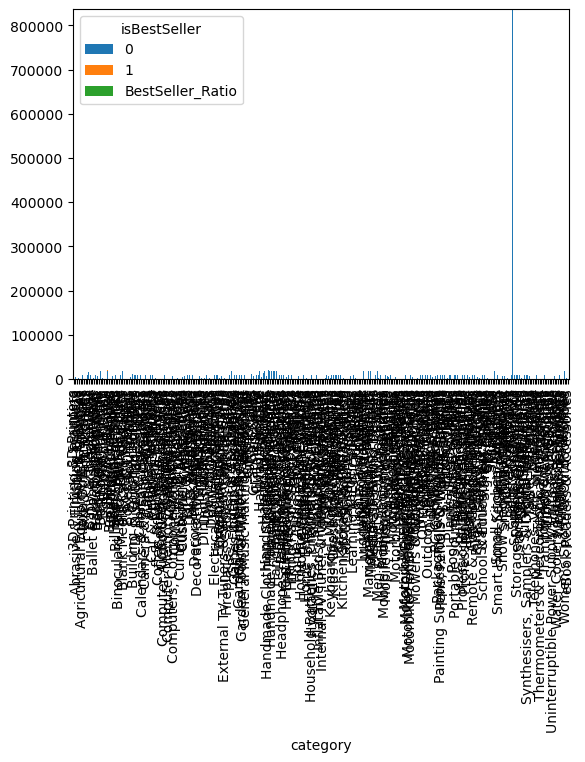

In [13]:
crosstab.plot(kind="bar", stacked=True)

## Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective: Investigate how different product categories influence product prices.**

In [14]:
# Preliminary Step: Remove outliers in product prices

q1_price = amzUK_df['price'].quantile(0.25)
q3_price = amzUK_df['price'].quantile(0.75)
iqr_price = q3_price - q1_price

In [17]:
lower_bound = q1_price - 1.5 * iqr_price
upper_bound = q3_price + 1.5 * iqr_price

In [32]:
# the dataframe without outliers
amzUK_df_cleaned = amzUK_df[(amzUK_df['price']>= lower_bound) & (amzUK_df['price']<= upper_bound)]

In [33]:
# Filter out the top 20 categories based on count
top_20_categories = amzUK_df_cleaned['category'].value_counts().head(20).index
top_20_categories

Index(['Sports & Outdoors', 'Beauty', 'Bath & Body',
       'Manicure & Pedicure Products',
       'Handmade Clothing, Shoes & Accessories', 'Make-up', 'Skin Care',
       'Hair Care', 'Birthday Gifts', 'Handmade Gifts', 'Handmade Home Décor',
       'Luggage and travel gear', 'Women', 'Fragrances',
       'Handmade Kitchen & Dining', 'Handmade Artwork',
       'Handmade Home & Kitchen Products', 'Handmade Jewellery', 'Men',
       'Baby'],
      dtype='object', name='category')

C:\Users\tevfi\AppData\Local\Temp\ipykernel_2476\2136726234.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=amzUK_df_cleaned[amzUK_df_cleaned['category'].isin(top_20_categories)], x='category', y='price', palette="coolwarm")


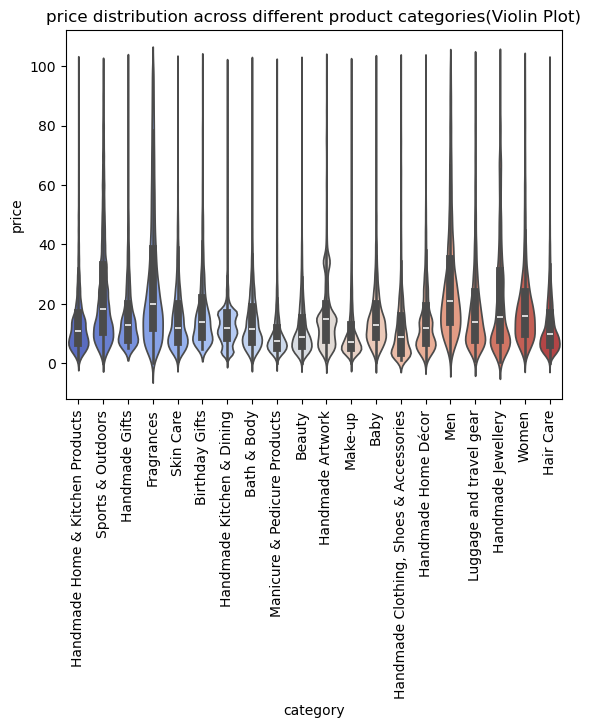

In [34]:
sns.violinplot(data=amzUK_df_cleaned[amzUK_df_cleaned['category'].isin(top_20_categories)], x='category', y='price', palette="coolwarm")
plt.xticks(rotation=90)  # Kategorilerin daha iyi görünmesi için
plt.title('price distribution across different product categories(Violin Plot)')
plt.show()

In [39]:
# Bar Charts 

top_10_avg_price = amzUK_df_cleaned.groupby('category')['price'].mean().nlargest(10)
top_10_avg_price

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

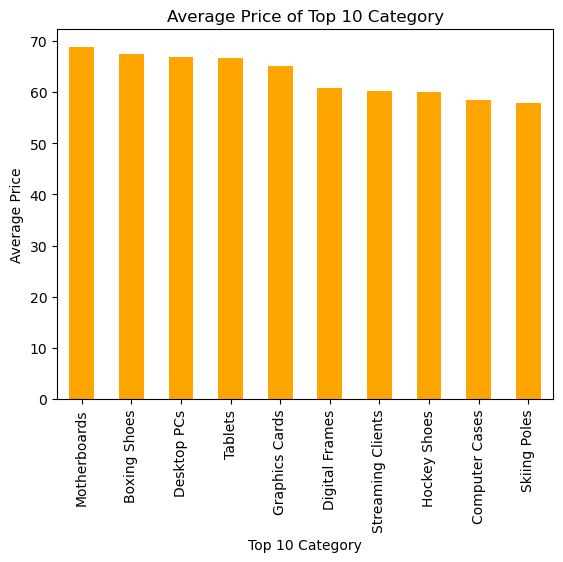

In [41]:
top_10_avg_price.plot(kind='bar', color='orange')
plt.title('Average Price of Top 10 Category')
plt.ylabel('Average Price')
plt.xlabel('Top 10 Category')
plt.show

In [49]:
top_10_category = amzUK_df_cleaned['category'].value_counts().head(10).index
top_10_category

Index(['Sports & Outdoors', 'Beauty', 'Bath & Body',
       'Manicure & Pedicure Products',
       'Handmade Clothing, Shoes & Accessories', 'Make-up', 'Skin Care',
       'Hair Care', 'Birthday Gifts', 'Handmade Gifts'],
      dtype='object', name='category')

C:\Users\tevfi\AppData\Local\Temp\ipykernel_2476\664370187.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




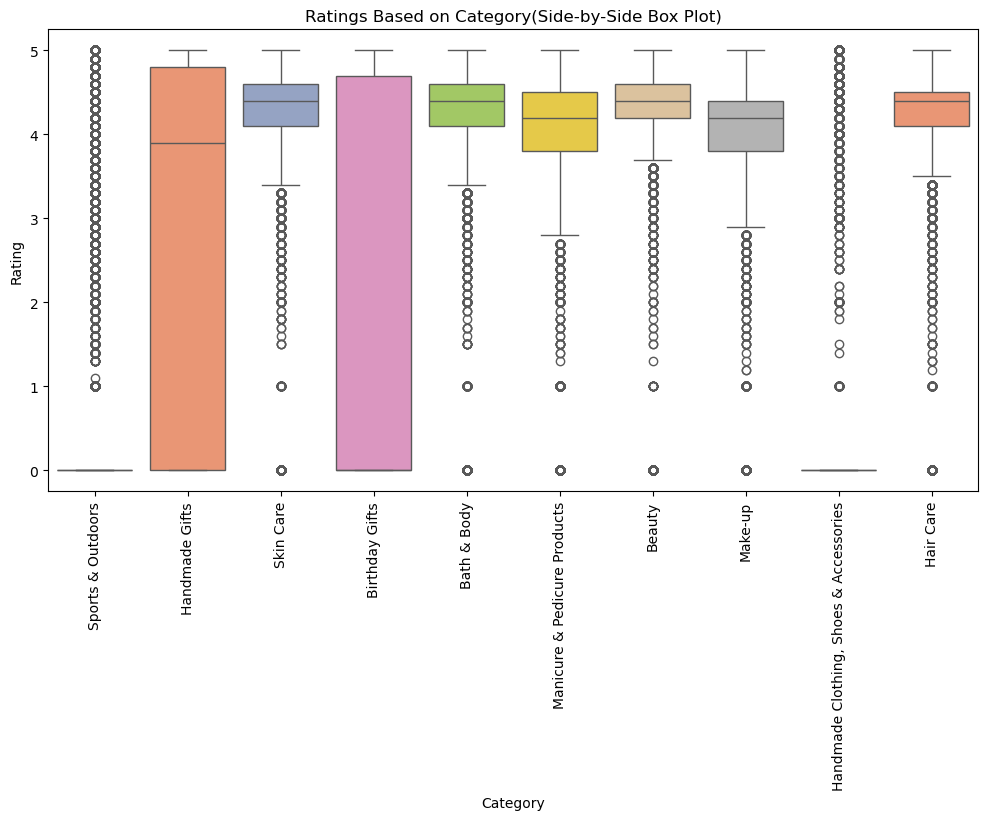

In [53]:
# Side-by-side box plot oluştur
plt.figure(figsize=(12, 6))
sns.boxplot(data=amzUK_df_cleaned[amzUK_df_cleaned['category'].isin(top_10_category)],
            x='category', y='stars', palette="Set2")

# Grafik ayarları
plt.xticks(rotation=90)
plt.title('Ratings Based on Category(Side-by-Side Box Plot)')
plt.ylabel('Rating')
plt.xlabel('Category')
plt.show()

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective: Analyze how product ratings (stars) correlate with product prices.**

In [ ]:
# Pearson correlation coefficient 
correlation_pearson = amzUK_df_cleaned['price'].corr(amzUK_df_cleaned['stars'])
correlation_pearson

-0.0776729987818137

In [65]:
# Calculating the Spearman rank correlation
correlation_spearman = amzUK_df_cleaned['price'].corr(amzUK_df_cleaned['stars'], method='spearman')
correlation_spearman

-0.06679697280768314

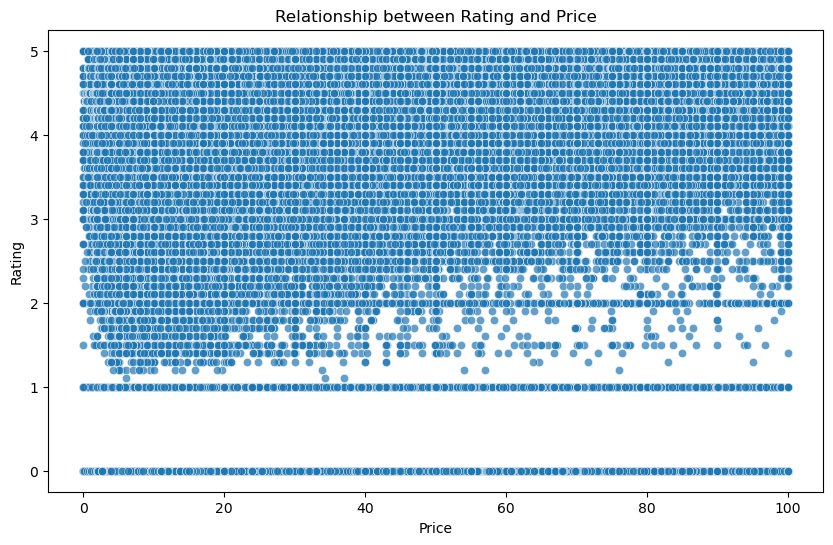

In [94]:
# 2. Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=amzUK_df_cleaned, x='price', y='stars', alpha=0.7)
plt.title('Relationship between Rating and Price')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.show()

In [89]:
# Separating between discrete and continuous variables, as discrete ones could potentially be treated as categorical.
# is for creating the heatmap to visualize correlations between all numerical variables.
potential_categorical_from_numerical = amzUK_df.select_dtypes("number").loc[:, amzUK_df.select_dtypes("number").nunique() < 10000000]
potential_categorical_from_numerical

,uid,stars,reviews,price,isBestSeller,boughtInLastMonth
0,1,4.7,15308,21.99,0,0
1,2,4.7,98099,23.99,1,0
2,3,4.7,15308,21.99,0,0
3,4,4.7,7205,31.99,0,0
4,5,4.6,1881,17.99,0,0
...,...,...,...,...,...,...
2443646,2828589,0.0,0,22.34,0,0
2443647,2828590,0.0,0,97.99,0,0
2443648,2828591,0.0,0,52.99,0,0
2443649,2828592,4.3,404,79.99,0,0


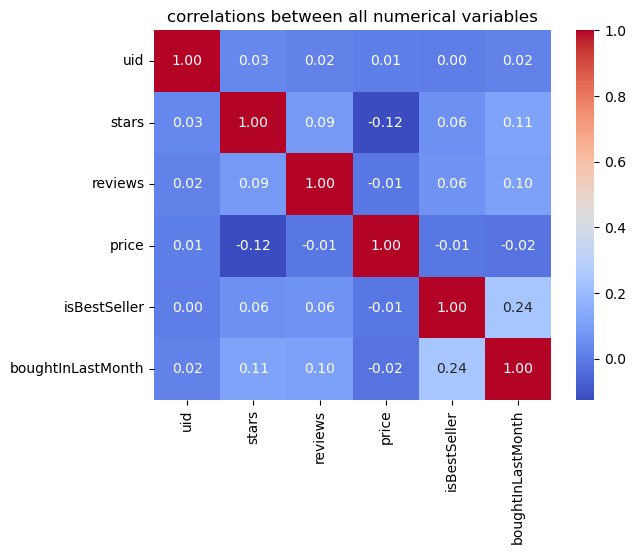

In [ ]:
# 3. correlations Heatmap
correlation_matrix = potential_categorical_from_numerical.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('correlations between all numerical variables')
plt.show()

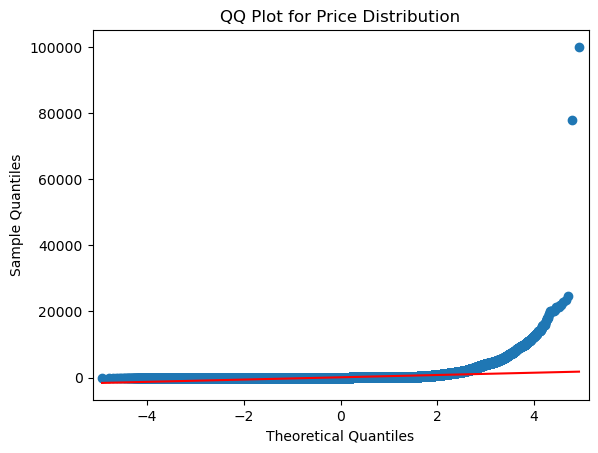

In [93]:
import statsmodels.api as sm

# Generating a Q-Q plot for 'price' to check if its distribution follows a normal distribution
sm.qqplot(amzUK_df['price'], line='s')
plt.title('QQ Plot for Price Distribution') 
plt.show()